In [9]:
import pandas as pd
data = pd.read_excel("data/Grove Rewards Data 04-10-2026.xlsx")
data.head()

,File number,AGCY_NBR,AGCY_CTY_NM,AGCY_ST_CDE,Agency Type,Producer ID,Region,Policy effective date,SUBMSN_DT,Quoted Premium,Written Premium,PROD_NM,OrgNAICS,TOT_WW_EMPL_NBR,Status,Coverage Combination,Final Criteria
0,1065951,2219,Dallas,TX,Wholesaler,1,South Central,2024-11-19,2024-10-09,3337,0,Trellis - 0323,722513.0,60.0,Lost,EPL,Not Eligible
1,1122387,4411,Walnut Creek,CA,Wholesaler,2,West,2025-10-09,2025-09-09,8329,0,MPS Trellis,722511.0,80.0,Quoted,EPL,Not Eligible
2,1122403,4411,Walnut Creek,CA,Wholesaler,2,West,2025-10-09,2025-09-09,9219,0,MPS Trellis,722511.0,85.0,Quoted,EPL,Not Eligible
3,1123475,2896,Malvern,PA,Wholesaler,3,Northeast,2025-11-14,2025-09-15,722,0,Trellis - 0323,541613.0,6.0,Quoted,EPL,Not Eligible
4,1013756,1540,New York,NY,Wholesaler,4,Northeast,2023-04-13,2023-03-14,0,0,Unknown,812990.0,NaN,Declined,NaN,Not Eligible


In [10]:
data["Final Criteria"].value_counts()

Final Criteria
Not Eligible             57680
Eligible Enrolled        55724
Eligible Not Enrolled    17558
Name: count, dtype: int64

Data Summary:
Final Criteria
Eligible Enrolled        16.231867
Not Eligible             14.355401
Eligible Not Enrolled     3.906118
Name: Policy Count, dtype: float64


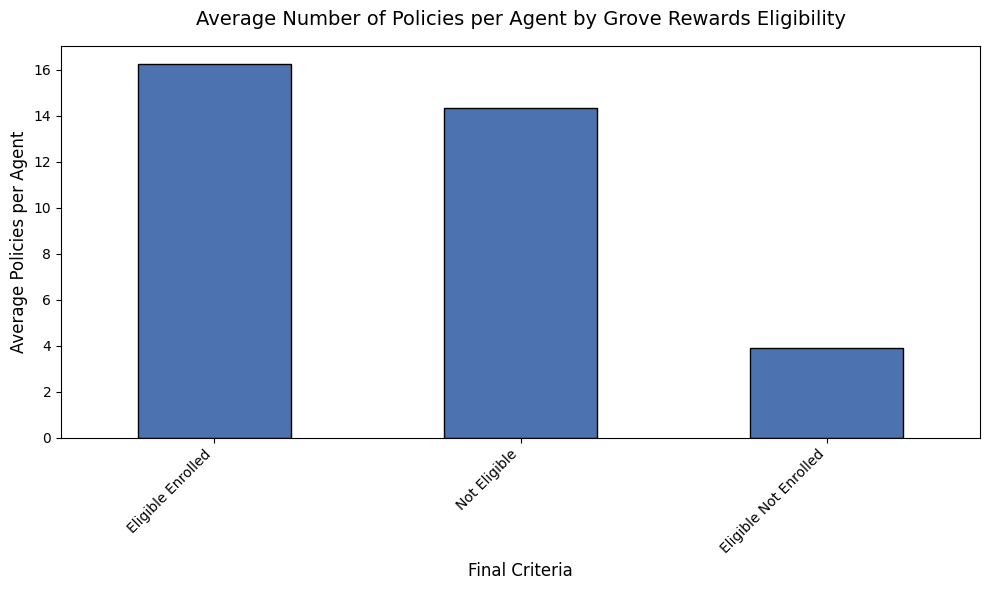

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your dataframe is already loaded and named 'data'

# 1. Count the number of policies (rows) per Producer ID within each Final Criteria
# This gives us a new dataframe with columns: Final Criteria, Producer ID, and Policy Count
producer_counts = data.groupby(['Final Criteria', 'Producer ID']).size().reset_index(name='Policy Count')

# 2. Calculate the average number of policies per agent for each Final Criteria
avg_policies = producer_counts.groupby('Final Criteria')['Policy Count'].mean()

# 3. Sort the values so the bar chart is organized from highest to lowest
avg_policies_sorted = avg_policies.sort_values(ascending=False)

# 4. Create the bar chart
fig, ax = plt.subplots(figsize=(10, 6))

avg_policies_sorted.plot(kind='bar', ax=ax, color='#4C72B0', edgecolor='black')

# 5. Format the chart
ax.set_title('Average Number of Policies per Agent by Grove Rewards Eligibility', fontsize=14, pad=15)
ax.set_xlabel('Final Criteria', fontsize=12)
ax.set_ylabel('Average Policies per Agent', fontsize=12)

# Rotate the x-axis labels so they are easily readable and do not overlap
ax.tick_params(axis='x', rotation=45)
plt.xticks(ha='right')

# Ensure nothing gets truncated in the final image
fig.tight_layout()

# Save the generated graph as an image file
plt.savefig('average_policies_by_criteria.png')

# Print the data summary to the console as well
print("Data Summary:")
print(avg_policies_sorted)

Data Summary (Issued Policies Only):
Final Criteria
Eligible Enrolled        5.022787
Not Eligible             4.475922
Eligible Not Enrolled    1.925880
Name: Policy Count, dtype: float64


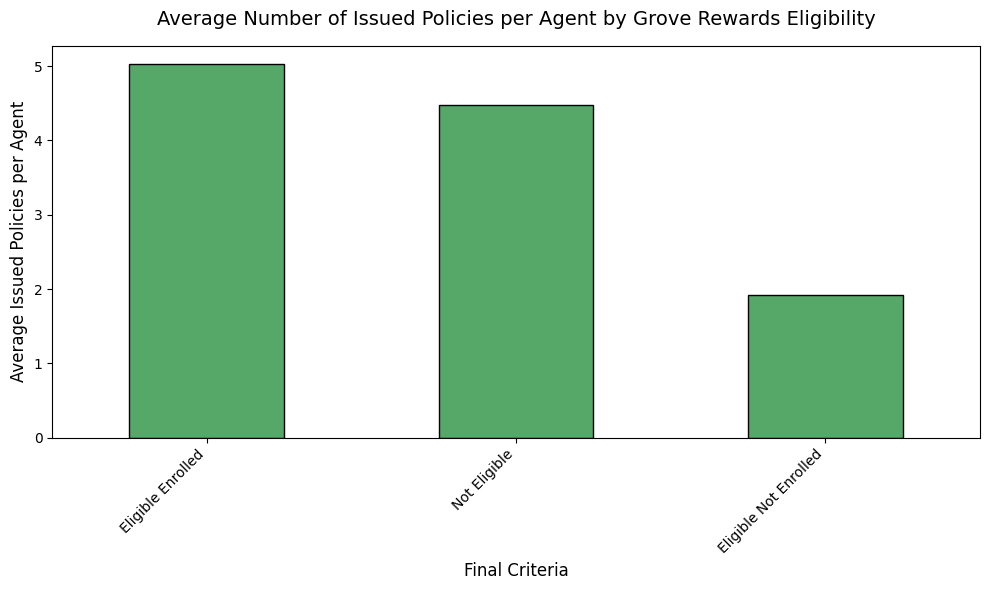

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your dataframe is already loaded and named 'data'

# 0. Filter the data to ONLY include 'Issued' policies
issued_data = data[data['Status'] == 'Issued']

# 1. Count the number of issued policies per Producer ID within each Final Criteria
producer_counts = issued_data.groupby(['Final Criteria', 'Producer ID']).size().reset_index(name='Policy Count')

# 2. Calculate the average number of issued policies per agent for each Final Criteria
avg_policies = producer_counts.groupby('Final Criteria')['Policy Count'].mean()

# 3. Sort the values so the bar chart is organized from highest to lowest
avg_policies_sorted = avg_policies.sort_values(ascending=False)

# 4. Create the bar chart
fig, ax = plt.subplots(figsize=(10, 6))

# Added a slightly different color (e.g., green for issued) to differentiate from the previous chart if needed
avg_policies_sorted.plot(kind='bar', ax=ax, color='#55A868', edgecolor='black')

# 5. Format the chart
ax.set_title('Average Number of Issued Policies per Agent by Grove Rewards Eligibility', fontsize=14, pad=15)
ax.set_xlabel('Final Criteria', fontsize=12)
ax.set_ylabel('Average Issued Policies per Agent', fontsize=12)

# Rotate the x-axis labels so they are easily readable and do not overlap
ax.tick_params(axis='x', rotation=45)
plt.xticks(ha='right')

# Ensure nothing gets truncated in the final image
fig.tight_layout()

# Save the generated graph as an image file
plt.savefig('average_issued_policies_by_criteria.png')

# Print the data summary to the console
print("Data Summary (Issued Policies Only):")
print(avg_policies_sorted)

**Quote Ratio**: # quoted / # all (the percentage of submissions that received a quote out of all submissions)

In [ ]:
data["Status"].value_counts()

Status
Quoted        41981
Declined      31710
Lost          22773
Issued        21737
Incomplete     7525
Indicated      5236
Name: count, dtype: int64

In [ ]:
import pandas as pd

# Calculate the ratio for all statuses (returns decimals like 0.50)
status_ratios = data['Status'].value_counts(normalize=True)

# Convert to percentages and format with the '%' sign
status_percentages = (status_ratios * 100).round(2).astype(str) + '%'

# Display the results
print("Ratios for all statuses:")
print(status_percentages)

Ratios for all statuses:
Status
Quoted        32.06%
Declined      24.21%
Lost          17.39%
Issued         16.6%
Incomplete     5.75%
Indicated       4.0%
Name: proportion, dtype: str


**Hit Ratio:** # issued / (# issued + # quoted) 

In [ ]:
import pandas as pd

# 1. Count the number of Issued policies
issued_count = len(data[data['Status'] == 'Issued'])

# 2. Count the number of Quoted policies
quoted_count = len(data[data['Status'] == 'Quoted'])

# 3. Calculate the denominator (Issued + Quoted)
denominator = issued_count + quoted_count

# 4. Calculate the Hit Ratio (with a safety check to prevent dividing by zero)
if denominator > 0:
    hit_ratio = issued_count / denominator
    print(f"Hit Ratio: {hit_ratio * 100:.2f}%")
else:
    print("Hit Ratio: N/A (No Issued or Quoted policies in dataset)")

Hit Ratio: 34.11%
